# 02 - Tarea 1: LeNet-5 y VGG-11 (con/sin Batch Normalization)
Entrenamiento desde cero de 4 variantes con **3 semillas** (42, 43, 44) cada una, para reportar media ± desviación. Config: Adam, lr=1e-3, batch=64, 20 épocas, entrada 64×64. El split train/val es fijo; solo cambia la semilla de inicialización, barajado y augmentation. Se restaura el checkpoint con mejor accuracy de validación y con él se evalúa en TEST.

In [1]:
import sys, json; sys.path.append('../src')
import pandas as pd  # importar pandas ANTES que torch: evita un crash del kernel en Windows
import numpy as np, torch, matplotlib.pyplot as plt, seaborn as sns
from sklearn.metrics import confusion_matrix
from utils import get_loaders, FIG_DIR, ROOT, CLASSES
from models import build_model
from train import run_experiment

RES_DIR = ROOT/'results'; CKPT_DIR = RES_DIR/'checkpoints'; CKPT_DIR.mkdir(parents=True, exist_ok=True)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device, torch.cuda.get_device_name(0) if device.type == 'cuda' else '')
EPOCHS, LR, BS, SEEDS = 20, 1e-3, 64, [42, 43, 44]
train_loader, val_loader, test_loader = get_loaders(img_size=64, batch_size=BS)

cuda NVIDIA GeForce RTX 4050 Laptop GPU


## Entrenamiento: 4 variantes × 3 semillas

In [2]:
VARIANTS = {'lenet': ('lenet', False), 'lenet_bn': ('lenet', True),
            'vgg11': ('vgg11', False), 'vgg11_bn': ('vgg11', True)}
runs = {t: [] for t in VARIANTS}
for tag, (name, bn) in VARIANTS.items():
    for s in SEEDS:
        r = run_experiment(lambda: build_model(name, bn), tag, train_loader, val_loader, test_loader,
                           EPOCHS, LR, device, s, CKPT_DIR)
        runs[tag].append(r)
        print(f"{tag:9s} seed {s} | params {r['params']:,} | best val {max(r['hist']['val_acc']):.4f} | test {r['test_acc']:.4f}")

lenet     seed 42 | params 337,976 | best val 0.9726 | test 0.6840


lenet     seed 43 | params 337,976 | best val 0.9264 | test 0.5657


lenet     seed 44 | params 337,976 | best val 0.9652 | test 0.7214


lenet_bn  seed 42 | params 337,998 | best val 0.9538 | test 0.6868


lenet_bn  seed 43 | params 337,998 | best val 0.9632 | test 0.6695


...

vgg11     seed 43 | params 3,095,748 | best val 0.2671 | test 0.2770


vgg11     seed 44 | params 3,095,748 | best val 0.9786 | test 0.8814


vgg11_bn  seed 42 | params 3,097,124 | best val 0.9772 | test 0.8456


vgg11_bn  seed 43 | params 3,097,124 | best val 0.9866 | test 0.8347


vgg11_bn  seed 44 | params 3,097,124 | best val 0.9819 | test 0.8737


## Tabla resumen (media ± desviación sobre 3 semillas)

In [3]:
def first_epoch_over(h, thr=0.8):
    return next((i+1 for i, a in enumerate(h['val_acc']) if a >= thr), np.nan)

ms = lambda v, d=4: f"{np.mean(v):.{d}f} ± {np.std(v):.{d}f}"
rows = []
for t, rs in runs.items():
    rows.append({'Modelo': t, 'Parámetros': rs[0]['params'],
                 'Tiempo/época (s)': ms([np.mean(r['hist']['epoch_time'][1:]) for r in rs], 2),
                 'Mejor val acc': ms([max(r['hist']['val_acc']) for r in rs]),
                 'Test acc': ms([r['test_acc'] for r in rs]),
                 'Épocas a 80% val': ms([first_epoch_over(r['hist']) for r in rs], 1)})
summary = pd.DataFrame(rows); summary.to_csv(RES_DIR/'t1_resumen.csv', index=False)
json.dump({t: [dict(seed=r['seed'], params=r['params'], hist=r['hist'], test_acc=r['test_acc'],
                    test_loss=r['test_loss'], y_true=r['y_true'], y_pred=r['y_pred']) for r in rs]
           for t, rs in runs.items()}, open(RES_DIR/'t1_resultados.json', 'w'))
summary

,Modelo,Parámetros,Tiempo/época (s),Mejor val acc,Test acc,Épocas a 80% val
0,lenet,337976,1.11 ± 0.39,0.9547 ± 0.0203,0.6570 ± 0.0663,6.3 ± 1.2
1,lenet_bn,337998,1.43 ± 0.21,0.9525 ± 0.0093,0.6223 ± 0.0793,5.0 ± 0.8
2,vgg11,3095748,3.27 ± 0.03,0.5009 ± 0.3378,0.4725 ± 0.2892,nan ± nan
3,vgg11_bn,3097124,3.81 ± 0.07,0.9819 ± 0.0038,0.8514 ± 0.0164,9.0 ± 1.6


In [4]:
# detalle por semilla
pd.DataFrame([{'Modelo': t, 'Semilla': r['seed'], 'Mejor val acc': round(max(r['hist']['val_acc']), 4),
               'Test acc': round(r['test_acc'], 4)} for t, rs in runs.items() for r in rs]).pivot(
    index='Modelo', columns='Semilla', values=['Mejor val acc', 'Test acc'])

Mejor val acc                 Test acc                
Semilla             42      43      44       42      43      44
Modelo                                                         
lenet           0.9726  0.9264  0.9652   0.6840  0.5657  0.7214
lenet_bn        0.9538  0.9632  0.9404   0.6868  0.6695  0.5107
vgg11           0.2570  0.2671  0.9786   0.2589  0.2770  0.8814
vgg11_bn        0.9772  0.9866  0.9819   0.8456  0.8347  0.8737

## Curvas de pérdida y accuracy (media ± desviación entre semillas)

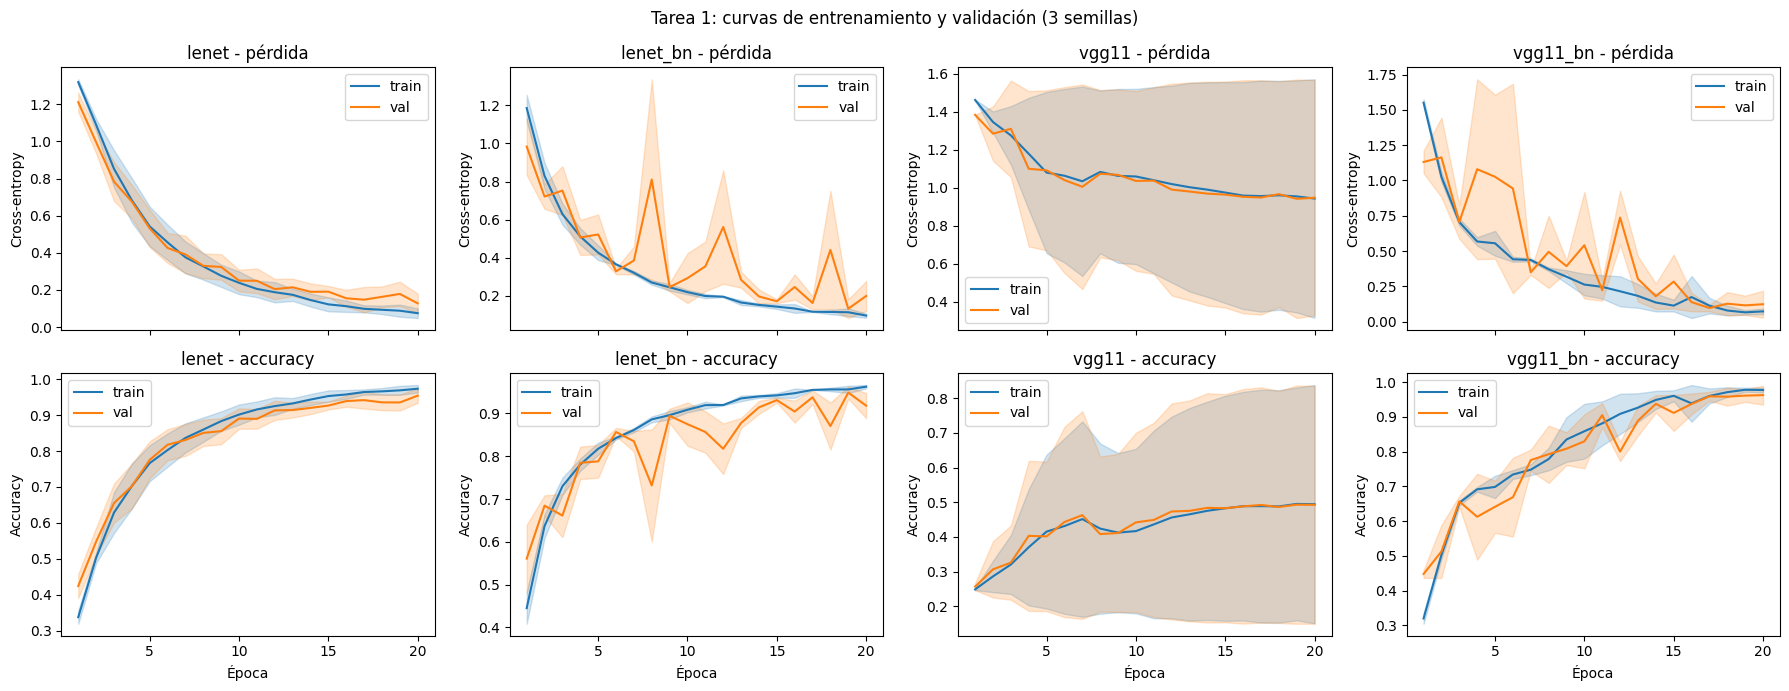

In [5]:
fig, axs = plt.subplots(2, 4, figsize=(18, 7), sharex=True)
for j, (t, rs) in enumerate(runs.items()):
    ep = np.arange(1, EPOCHS+1)
    for i, (k, lab) in enumerate([('loss', 'Cross-entropy'), ('acc', 'Accuracy')]):
        for split, col in [('train', 'tab:blue'), ('val', 'tab:orange')]:
            a = np.array([r['hist'][f'{split}_{k}'] for r in rs]); m, s = a.mean(0), a.std(0)
            axs[i, j].plot(ep, m, color=col, label=split); axs[i, j].fill_between(ep, m-s, m+s, color=col, alpha=.2)
        axs[i, j].set_title(f"{t} - {'pérdida' if k == 'loss' else 'accuracy'}"); axs[i, j].set_ylabel(lab)
        axs[i, j].legend()
    axs[1, j].set_xlabel('Época')
fig.suptitle('Tarea 1: curvas de entrenamiento y validación (3 semillas)'); plt.tight_layout()
plt.savefig(FIG_DIR/'t1_curvas.png', dpi=150); plt.show()

## Diagnóstico de la brecha validación → test
Matriz de confusión en TEST (semilla 42) y accuracy por clase, para ver qué clases fallan.

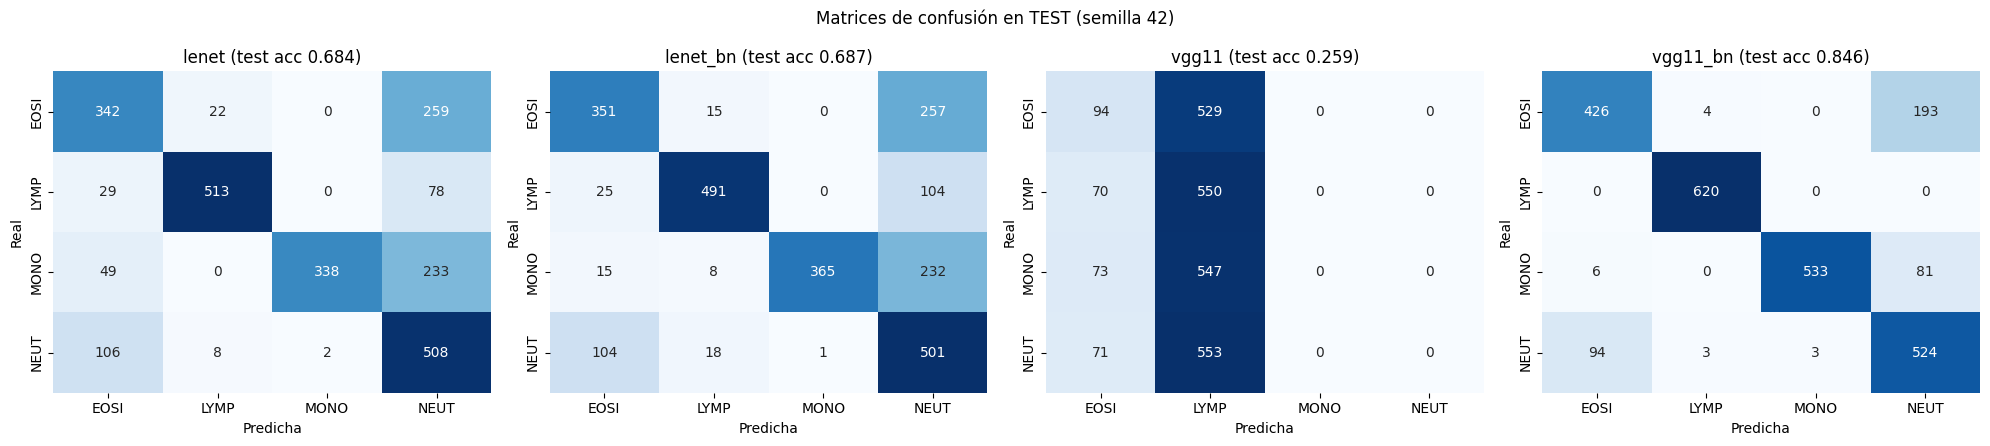

,lenet,lenet_bn,vgg11,vgg11_bn
EOSINOPHIL,0.549,0.563,0.151,0.684
LYMPHOCYTE,0.827,0.792,0.887,1.000
MONOCYTE,0.545,0.589,0.000,0.860
NEUTROPHIL,0.814,0.803,0.000,0.840


In [6]:
fig, axs = plt.subplots(1, 4, figsize=(20, 4.5))
for ax, (t, rs) in zip(axs, runs.items()):
    r = rs[0]; cm = confusion_matrix(r['y_true'], r['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax,
                xticklabels=[c[:4] for c in CLASSES], yticklabels=[c[:4] for c in CLASSES])
    ax.set_title(f"{t} (test acc {r['test_acc']:.3f})"); ax.set_xlabel('Predicha'); ax.set_ylabel('Real')
fig.suptitle('Matrices de confusión en TEST (semilla 42)'); plt.tight_layout()
plt.savefig(FIG_DIR/'t1_confusion_test.png', dpi=150); plt.show()
pd.DataFrame({t: np.diag(confusion_matrix(rs[0]['y_true'], rs[0]['y_pred'], normalize='true')).round(3)
              for t, rs in runs.items()}, index=CLASSES)